In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [20]:
def snr_mf(A,T,sigma):
    delta = A**2/T
    return ((np.pi)**3)/(2*(np.pi + 4))*(delta)/(sigma**2)

In [3]:
np.random.seed(12345)
jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

In [4]:
def pattern(i,z,a):
    return [int(a*np.cos((np.pi*i)/z)), int(a*np.sin((np.pi*i)/z))]

In [10]:
#defining a standard model for the cnn
input_shape = (L, 2)
n_class = 3 
                
reg = tf.keras.regularizers.l2(0.2)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
NF = 5 
model = Sequential()
model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape))
model.add(AveragePooling1D(5))
model.add(Conv1D(filters=5, kernel_size=7, 
                 activation='relu'))
model.add(Flatten())
model.add(Dense(12, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(n_class, activation='softmax')) # softmax !

print(model.summary())

opt = tf.keras.optimizers.Adam()

# compile the model
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 50, 5)          │           115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 586 (2.29 KB)

 Trainable params: 586 (2.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
#Generation of 8 datasets with different amplitudes
Z=12

N=10000
L=60

DX1 = 50 
bias1 = 5 
DX2 = 20
bias2 = 10

y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L,2))

for A in range(100, 900, 100):
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX({DX1,DX2})_bias({bias1,bias2})_N{N}'
    print(str0)
    
    for i in range(N):
        if i>0: 
            jump0, jump1 = jump(bias1, bias2, DX1, DX2)
            x[i][0][0] = x[i-1][-1][0] + jump0 
            x[i][0][1] = x[i-1][-1][1] + jump1
        
        for j in range(1,L):
            jump0, jump1 = jump(bias1, bias2, DX1, DX2)
            x[i][j][0] = x[i][j-1][0] + jump0
            x[i][j][1] = x[i][j-1][1] + jump1
            
        y[i] = i%3 # assign class labels (0,1,2)
               
        if y[i]>0:
            j0 = np.random.randint(0,L-1-Z) 
            sign = 3-2*y[i] 
            for j in range(Z): 
                x[i][j0+j][0] += sign*pattern(j,Z,A)[0]
                x[i][j0+j][1] += sign*pattern(j,Z,A)[1]

    fname='x'+str0
    np.save(fname,x)
    fname='y'+str0
    np.save(fname,y)

ts_L60_Z12_A100_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A200_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A300_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A400_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A500_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A600_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A700_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A800_DX((50, 20))_bias((5, 10))_N10000


In [17]:
#training the cnn over different datasets
BATCH_SIZE = 200
EPOCHS = 10
best_acc = 0
j = 0
models = []
acc = []

for A in range(100,900,100):
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX({DX1,DX2})_bias({bias1,bias2})_N{N}.npy'
    fnamex='x'+str0
    fnamey='y'+str0
    
    x = np.load(fnamex)
    
    N,L = len(x), len(x[0])

    categ = np.load(fnamey)
    
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    # split into training and validation sets
    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)

    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=0, shuffle=True) 
    
    models.append(fit)    
    acc.append(fit.history['val_accuracy'][-1])
    
    if fit.history['val_accuracy'][-1] > best_acc:
        best_acc = fit.history['val_accuracy'][-1]
        best_model = fit
        best_A = A

    print(f"Training dataset: {j}")
    j+=1

Training dataset: 0
Training dataset: 1
Training dataset: 2
Training dataset: 3
Training dataset: 4
Training dataset: 5
Training dataset: 6
Training dataset: 7


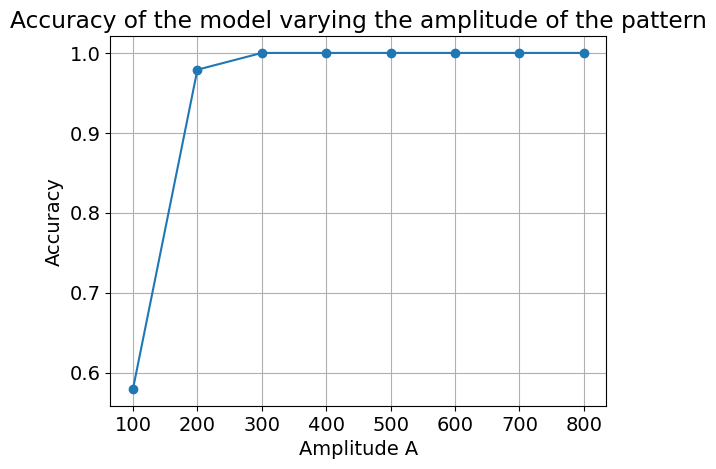

In [18]:
plt.plot(np.arange(100, 900, 100), acc, marker='o')
plt.xlabel("Amplitude A")
plt.ylabel("Accuracy")
plt.title("Accuracy of the model varying the amplitude of the pattern")
plt.grid()
plt.show()

In [25]:
SNR_mf = []
for A in range(100,900,100):
    SNR_mf.append(snr_mf(A,Z,np.mean([DX1,DX2])))

[1.4767507927024717,
 5.907003170809887,
 13.290757134322245,
 23.628012683239547,
 36.91876981756179,
 53.16302853728898,
 72.36078884242112,
 94.51205073295819]

In [26]:
for x, y in zip(SNR_mf, acc):
    print(x, y)

1.4767507927024717 0.5795000195503235
5.907003170809887 0.9789999723434448
13.290757134322245 1.0
23.628012683239547 1.0
36.91876981756179 1.0
53.16302853728898 1.0
72.36078884242112 1.0
94.51205073295819 1.0


In [32]:
print(list(zip(SNR_mf, acc)))

[(1.4767507927024717, 0.5795000195503235), (5.907003170809887, 0.9789999723434448), (13.290757134322245, 1.0), (23.628012683239547, 1.0), (36.91876981756179, 1.0), (53.16302853728898, 1.0), (72.36078884242112, 1.0), (94.51205073295819, 1.0)]


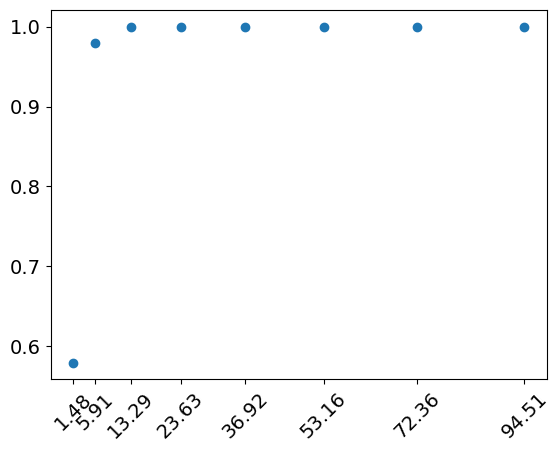

In [34]:
plt.scatter(SNR_mf, acc)
plt.xticks(SNR_mf, rotation=45) 

plt.show()